In [2]:
# ==============================================================
# MODEL 5 — OUTLIER DETECTOR
# STEP 1 — LOAD DATASET
# ==============================================================

import pandas as pd
import numpy as np

print("=" * 70)
print("MODEL 5 — OUTLIER DETECTOR")
print("=" * 70)

# Load dataset
df = pd.read_csv("../data/raw/final_dataset.csv")

# Convert Date
df["Date"] = pd.to_datetime(
    df["Date"],
    errors="coerce"
)

print("\nDataset shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

# Required columns
required_columns = [
    "Date",
    "Commodity",
    "Modal_Price",
    "Arrival",
    "Price_Change"
]

print("\nRequired columns check:")

for column in required_columns:
    print(
        f"{column:15} -> {column in df.columns}"
    )

# Remove rows with missing required values
df = df.dropna(
    subset=required_columns
).copy()

# Sort
df = df.sort_values(
    ["Commodity", "Date"]
).reset_index(drop=True)

print("\nRows after cleaning:", len(df))

print("\nCommodities:")
print(
    df["Commodity"]
    .unique()
    .tolist()
)

MODEL 5 — OUTLIER DETECTOR



Dataset shape: (54340, 28)

Columns:
['State', 'Commodity_Group', 'Commodity', 'Date', 'Arrival', 'Arrival_Unit', 'Modal_Price', 'Price_Unit', 'District', 'Max_Temp', 'Min_Temp', 'Rainfall_mm', 'Rain_mm', 'WindSpeed', 'Festival', 'Holiday', 'Month', 'Year', 'Day', 'Weekend', 'DayOfWeek', 'Quarter', 'Lag_1', 'Lag_2', 'Lag_3', 'Rolling_7', 'Rolling_30', 'Price_Change']

Required columns check:
Date            -> True
Commodity       -> True
Modal_Price     -> True
Arrival         -> True
Price_Change    -> True

Rows after cleaning: 54340

Commodities:
['Onion', 'Potato', 'Rice', 'Tomato', 'Wheat']


In [3]:
# ==============================================================
# STEP 2 — CREATE OUTLIER FEATURES
# ==============================================================

print("\n" + "=" * 70)
print("STEP 2 — CREATING OUTLIER FEATURES")
print("=" * 70)


# --------------------------------------------------------------
# Price change percentage
# --------------------------------------------------------------

df["Price_Change_Percent"] = (
    df.groupby("Commodity")["Modal_Price"]
    .pct_change() * 100
)


# --------------------------------------------------------------
# Rolling price statistics
# --------------------------------------------------------------

df["Price_Rolling_Mean"] = (
    df.groupby("Commodity")["Modal_Price"]
    .transform(
        lambda x: x.rolling(
            window=30,
            min_periods=5
        ).mean()
    )
)


df["Price_Rolling_Std"] = (
    df.groupby("Commodity")["Modal_Price"]
    .transform(
        lambda x: x.rolling(
            window=30,
            min_periods=5
        ).std()
    )
)


# --------------------------------------------------------------
# Price deviation from rolling average
# --------------------------------------------------------------

df["Price_Deviation"] = (
    df["Modal_Price"]
    - df["Price_Rolling_Mean"]
)


# --------------------------------------------------------------
# Arrival rolling statistics
# --------------------------------------------------------------

df["Arrival_Rolling_Mean"] = (
    df.groupby("Commodity")["Arrival"]
    .transform(
        lambda x: x.rolling(
            window=30,
            min_periods=5
        ).mean()
    )
)


df["Arrival_Rolling_Std"] = (
    df.groupby("Commodity")["Arrival"]
    .transform(
        lambda x: x.rolling(
            window=30,
            min_periods=5
        ).std()
    )
)


# --------------------------------------------------------------
# Supply deviation
# --------------------------------------------------------------

df["Arrival_Deviation"] = (
    df["Arrival"]
    - df["Arrival_Rolling_Mean"]
)


# --------------------------------------------------------------
# Final anomaly features
# --------------------------------------------------------------

outlier_features = [
    "Modal_Price",
    "Price_Change_Percent",
    "Price_Deviation",
    "Arrival",
    "Arrival_Deviation"
]


print("\nOutlier features:")

for feature in outlier_features:
    print("✓", feature)


# --------------------------------------------------------------
# Check missing values
# --------------------------------------------------------------

print("\nMissing values:")

print(
    df[outlier_features]
    .isnull()
    .sum()
)


# --------------------------------------------------------------
# Remove rows where rolling features aren't available
# --------------------------------------------------------------

df = df.dropna(
    subset=outlier_features
).copy()


print("\nRows after feature creation:", len(df))

print("\nFeature data shape:")
print(
    df[outlier_features].shape
)


STEP 2 — CREATING OUTLIER FEATURES

Outlier features:
✓ Modal_Price
✓ Price_Change_Percent
✓ Price_Deviation
✓ Arrival
✓ Arrival_Deviation

Missing values:
Modal_Price              0
Price_Change_Percent     5
Price_Deviation         20
Arrival                  0
Arrival_Deviation       20
dtype: int64

Rows after feature creation: 54320

Feature data shape:
(54320, 5)


In [4]:
# ==============================================================
# STEP 3 — TRAIN ISOLATION FOREST
# ==============================================================

from sklearn.ensemble import IsolationForest


print("\n" + "=" * 70)
print("STEP 3 — TRAINING ISOLATION FOREST")
print("=" * 70)


# ==============================================================
# SETTINGS
# ==============================================================

# Expected percentage of abnormal observations.
# 2% means approximately 2 out of every 100 observations
# may be classified as anomalies.

CONTAMINATION = 0.02

commodities = sorted(
    df["Commodity"].unique()
)

print("\nCommodities:")
print(commodities)

print(
    "\nContamination:",
    CONTAMINATION
)


# ==============================================================
# STORAGE
# ==============================================================

outlier_models = {}
outlier_results = {}


# ==============================================================
# TRAIN ONE MODEL FOR EACH COMMODITY
# ==============================================================

for commodity in commodities:

    print("\n" + "=" * 60)
    print(commodity)
    print("=" * 60)


    # ----------------------------------------------------------
    # Select commodity
    # ----------------------------------------------------------

    commodity_data = df[
        df["Commodity"] == commodity
    ].copy()


    # ----------------------------------------------------------
    # Features
    # ----------------------------------------------------------

    X = commodity_data[
        outlier_features
    ]


    print(
        "Training rows:",
        len(X)
    )

    print(
        "Features:",
        X.shape[1]
    )


    # ----------------------------------------------------------
    # Train Isolation Forest
    # ----------------------------------------------------------

    model = IsolationForest(
        n_estimators=200,
        contamination=CONTAMINATION,
        random_state=42,
        n_jobs=-1
    )


    model.fit(X)


    # ----------------------------------------------------------
    # Predict anomaly
    # ----------------------------------------------------------

    predictions = model.predict(X)


    # Isolation Forest:
    #
    #  1  = normal
    # -1  = anomaly


    commodity_data["Outlier_Flag"] = predictions


    # ----------------------------------------------------------
    # Convert to easier labels
    # ----------------------------------------------------------

    commodity_data["Event_Type"] = np.where(
        commodity_data["Outlier_Flag"] == -1,
        "Abnormal Event",
        "Normal"
    )


    # ----------------------------------------------------------
    # Anomaly score
    # ----------------------------------------------------------

    commodity_data["Anomaly_Score"] = (
        model.decision_function(X)
    )


    # ----------------------------------------------------------
    # Store model
    # ----------------------------------------------------------

    outlier_models[
        commodity
    ] = model


    outlier_results[
        commodity
    ] = commodity_data


    # ----------------------------------------------------------
    # Summary
    # ----------------------------------------------------------

    total = len(
        commodity_data
    )

    anomalies = (
        commodity_data["Outlier_Flag"] == -1
    ).sum()

    normal = (
        commodity_data["Outlier_Flag"] == 1
    ).sum()


    anomaly_percent = (
        anomalies / total
    ) * 100


    print(
        "Total observations:",
        total
    )

    print(
        "Normal observations:",
        normal
    )

    print(
        "Abnormal observations:",
        anomalies
    )

    print(
        "Abnormal percentage:",
        round(
            anomaly_percent,
            2
        ),
        "%"
    )


# ==============================================================
# FINAL SUMMARY
# ==============================================================

print("\n" + "=" * 70)
print("ISOLATION FOREST TRAINING COMPLETED")
print("=" * 70)

print(
    "\nModels trained:",
    list(outlier_models.keys())
)

print(
    "\nResult datasets:",
    list(outlier_results.keys())
)


STEP 3 — TRAINING ISOLATION FOREST

Commodities:
['Onion', 'Potato', 'Rice', 'Tomato', 'Wheat']

Contamination: 0.02

Onion
Training rows: 10886
Features: 5
Total observations: 10886
Normal observations: 10668
Abnormal observations: 218
Abnormal percentage: 2.0 %

Potato
Training rows: 10866
Features: 5
Total observations: 10866
Normal observations: 10648
Abnormal observations: 218
Abnormal percentage: 2.01 %

Rice
Training rows: 10796
Features: 5
Total observations: 10796
Normal observations: 10580
Abnormal observations: 216
Abnormal percentage: 2.0 %

Tomato
Training rows: 10866
Features: 5
Total observations: 10866
Normal observations: 10648
Abnormal observations: 218
Abnormal percentage: 2.01 %

Wheat
Training rows: 10906
Features: 5
Total observations: 10906
Normal observations: 10687
Abnormal observations: 219
Abnormal percentage: 2.01 %

ISOLATION FOREST TRAINING COMPLETED

Models trained: ['Onion', 'Potato', 'Rice', 'Tomato', 'Wheat']

Result datasets: ['Onion', 'Potato', 'Ric

In [5]:
# ==============================================================
# STEP 4 — CLASSIFY ABNORMAL EVENTS
# ==============================================================

print("\n" + "=" * 70)
print("STEP 4 — CLASSIFYING ABNORMAL EVENTS")
print("=" * 70)


classified_results = {}


for commodity in commodities:

    print("\n" + "=" * 60)
    print(commodity)
    print("=" * 60)

    data = outlier_results[commodity].copy()

    # ----------------------------------------------------------
    # Calculate standardized price deviation
    # ----------------------------------------------------------

    price_z = (
        data["Price_Deviation"]
        / data["Price_Rolling_Std"].replace(0, np.nan)
    )

    # ----------------------------------------------------------
    # Calculate standardized arrival deviation
    # ----------------------------------------------------------

    arrival_z = (
        data["Arrival_Deviation"]
        / data["Arrival_Rolling_Std"].replace(0, np.nan)
    )

    price_z = price_z.fillna(0)
    arrival_z = arrival_z.fillna(0)

    data["Price_ZScore"] = price_z
    data["Arrival_ZScore"] = arrival_z

    # ----------------------------------------------------------
    # Define shock conditions
    # ----------------------------------------------------------

    price_shock = (
        data["Price_ZScore"].abs() >= 2
    )

    supply_shock = (
        data["Arrival_ZScore"].abs() >= 2
    )

    anomaly = (
        data["Outlier_Flag"] == -1
    )

    # ----------------------------------------------------------
    # Event classification
    # ----------------------------------------------------------

    data["Shock_Type"] = np.select(
        [
            anomaly & price_shock & supply_shock,
            anomaly & price_shock,
            anomaly & supply_shock
        ],
        [
            "Price + Supply Shock",
            "Price Shock",
            "Supply Shock"
        ],
        default="Other Abnormal Event"
    )

    # ----------------------------------------------------------
    # Store result
    # ----------------------------------------------------------

    classified_results[commodity] = data

    # ----------------------------------------------------------
    # Display summary
    # ----------------------------------------------------------

    print("\nEvent distribution:")

    print(
        data["Shock_Type"]
        .value_counts()
    )

    print("\nAbnormal events:")

    abnormal_events = data[
        data["Outlier_Flag"] == -1
    ]

    print(
        abnormal_events[
            [
                "Date",
                "Commodity",
                "Modal_Price",
                "Arrival",
                "Price_Change_Percent",
                "Anomaly_Score",
                "Shock_Type"
            ]
        ]
        .sort_values(
            "Anomaly_Score"
        )
        .head(10)
        .to_string(index=False)
    )


print("\n" + "=" * 70)
print("MODEL 5 — STEP 4 COMPLETED")
print("=" * 70)


STEP 4 — CLASSIFYING ABNORMAL EVENTS

Onion

Event distribution:
Shock_Type
Other Abnormal Event    10751
Price Shock                51
Price + Supply Shock       46
Supply Shock               38
Name: count, dtype: int64

Abnormal events:
      Date Commodity  Modal_Price  Arrival  Price_Change_Percent  Anomaly_Score           Shock_Type
2025-10-13     Onion       985.97 80038.12            -12.540139      -0.148269         Supply Shock
2024-11-24     Onion      4405.04  3553.67             23.143844      -0.138913 Price + Supply Shock
2023-03-27     Onion       689.39 70753.00            -17.548916      -0.134013         Supply Shock
2025-09-14     Onion      2239.81  8392.50            133.306251      -0.123859          Price Shock
2024-12-16     Onion      2190.56 43491.20            -30.629966      -0.110813          Price Shock
2024-11-20     Onion      2211.72    43.10            -36.484434      -0.109311          Price Shock
2024-11-17     Onion      4023.89  4555.76          


STEP 5 — OUTLIER VISUALIZATION

Total abnormal events: 1089


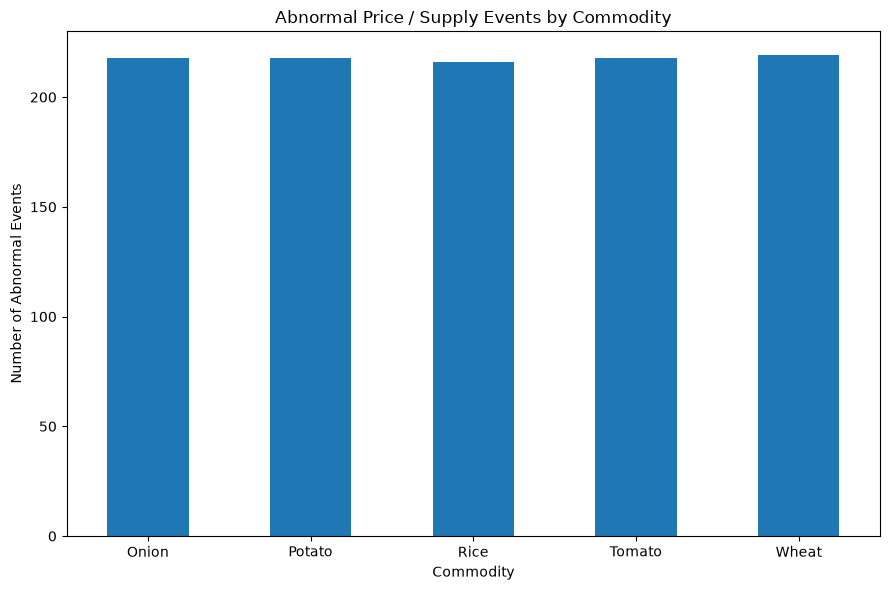

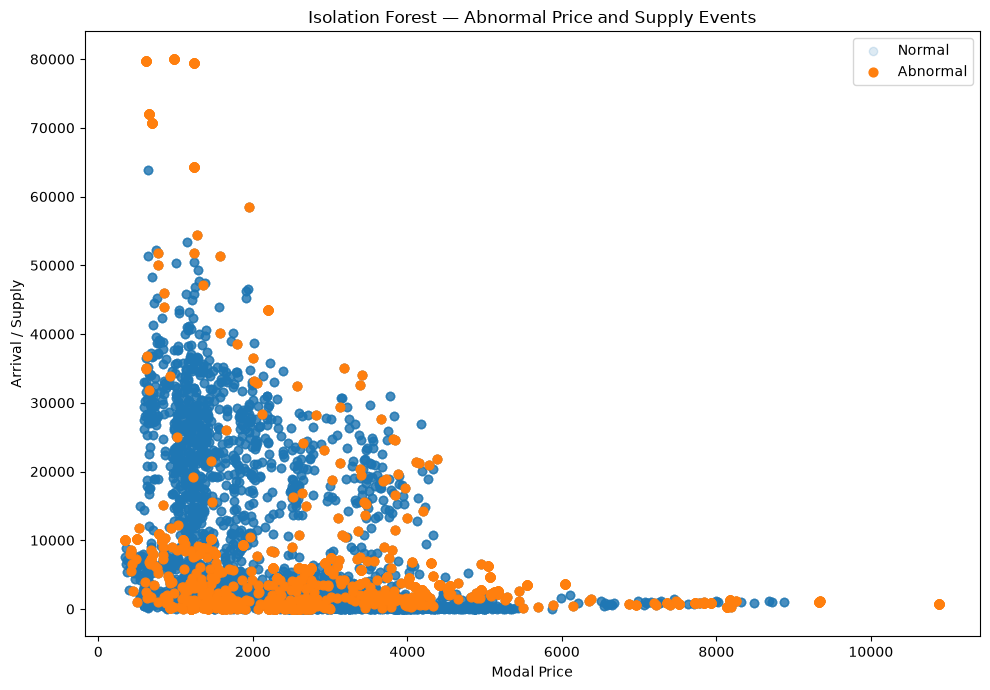

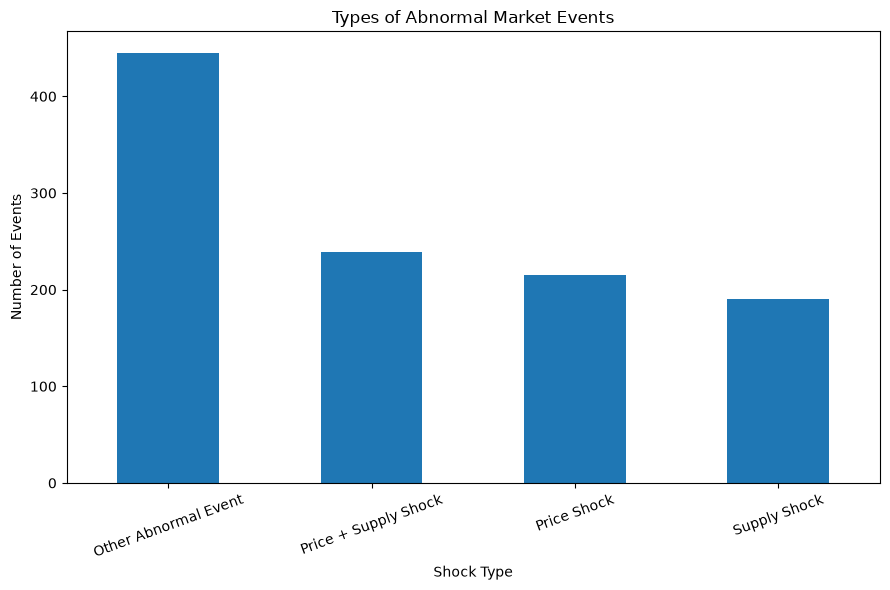


MODEL 5 — VISUALIZATION COMPLETED


In [6]:
# ==============================================================
# STEP 5 — OUTLIER VISUALIZATION
# ==============================================================

import matplotlib.pyplot as plt


print("\n" + "=" * 70)
print("STEP 5 — OUTLIER VISUALIZATION")
print("=" * 70)


# --------------------------------------------------------------
# Combine all commodity results
# --------------------------------------------------------------

all_outliers = pd.concat(
    classified_results.values(),
    ignore_index=True
)


# --------------------------------------------------------------
# Keep only abnormal events
# --------------------------------------------------------------

abnormal_data = all_outliers[
    all_outliers["Outlier_Flag"] == -1
].copy()


print(
    "\nTotal abnormal events:",
    len(abnormal_data)
)


# ==============================================================
# GRAPH 1 — ABNORMAL EVENTS BY COMMODITY
# ==============================================================

commodity_counts = (
    abnormal_data["Commodity"]
    .value_counts()
    .sort_index()
)


plt.figure(figsize=(9, 6))

commodity_counts.plot(
    kind="bar"
)

plt.title(
    "Abnormal Price / Supply Events by Commodity"
)

plt.xlabel("Commodity")
plt.ylabel("Number of Abnormal Events")

plt.xticks(
    rotation=0
)

plt.tight_layout()

plt.show()


# ==============================================================
# GRAPH 2 — PRICE VS ARRIVAL ANOMALIES
# ==============================================================

plt.figure(figsize=(10, 7))


normal_data = all_outliers[
    all_outliers["Outlier_Flag"] == 1
]


plt.scatter(
    normal_data["Modal_Price"],
    normal_data["Arrival"],
    alpha=0.15,
    label="Normal"
)


plt.scatter(
    abnormal_data["Modal_Price"],
    abnormal_data["Arrival"],
    s=40,
    label="Abnormal"
)


plt.xlabel("Modal Price")
plt.ylabel("Arrival / Supply")

plt.title(
    "Isolation Forest — Abnormal Price and Supply Events"
)

plt.legend()

plt.tight_layout()

plt.show()


# ==============================================================
# GRAPH 3 — SHOCK TYPE DISTRIBUTION
# ==============================================================

shock_counts = (
    abnormal_data["Shock_Type"]
    .value_counts()
)


plt.figure(figsize=(9, 6))

shock_counts.plot(
    kind="bar"
)

plt.title(
    "Types of Abnormal Market Events"
)

plt.xlabel("Shock Type")
plt.ylabel("Number of Events")

plt.xticks(
    rotation=20
)

plt.tight_layout()

plt.show()


print("\n" + "=" * 70)
print("MODEL 5 — VISUALIZATION COMPLETED")
print("=" * 70)

In [7]:
import os

os.makedirs("outputs", exist_ok=True)

# 1. All observations with anomaly information
all_outliers.to_csv(
    "outputs/outlier_detection_results.csv",
    index=False
)

# 2. Only abnormal events
abnormal_data.to_csv(
    "outputs/abnormal_price_supply_events.csv",
    index=False
)

print("=" * 70)
print("MODEL 5 — FILES SAVED SUCCESSFULLY")
print("=" * 70)

print("✓ outputs/outlier_detection_results.csv")
print("✓ outputs/abnormal_price_supply_events.csv")

print("\nTotal observations:", len(all_outliers))
print("Abnormal events:", len(abnormal_data))

MODEL 5 — FILES SAVED SUCCESSFULLY
✓ outputs/outlier_detection_results.csv
✓ outputs/abnormal_price_supply_events.csv

Total observations: 54320
Abnormal events: 1089
